<a href="https://colab.research.google.com/github/momo4201/Hodgkin-Huxley-Model-of-DBS-Electrode-Aging/blob/main/H_H_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks


In [ ]:
#Hodgkin-Huxley Parameters

#   - C_m  : membrane capacitance (how much charge it can store)
#   - g_Na : max Na⁺ conductance (how wide the Na channel can open)
#   - g_K  : max K⁺ conductance
#   - g_L  : leak (always-open background channels)
#   - E_Na, E_K, E_L : reversal potentials (where each current = 0)

C_m  = 1.0    # µF/cm²  — membrane capacitance
g_Na = 120.0  # mS/cm²  — max sodium conductance
g_K  = 36.0   # mS/cm²  — max potassium conductance
g_L  = 0.3    # mS/cm²  — leak conductance
E_Na = 50.0   # mV      — sodium reversal potential
E_K  = -77.0  # mV      — potassium reversal potential
E_L  = -54.4  # mV      — leak reversal potential

print("HH Parameters:")
print(f"  C_m  = {C_m}  µF/cm²")
print(f"  g_Na = {g_Na} mS/cm²  (Na channels, fast depolarisation)")
print(f"  g_K  = {g_K}  mS/cm²  (K channels, repolarisation)")
print(f"  g_L  = {g_L}  mS/cm²  (background leak)")
print(f"  E_Na = {E_Na} mV  (Na wants to push V positive)")
print(f"  E_K  = {E_K} mV (K wants to pull V negative)")
print(f"  E_L  = {E_L} mV")


HH Parameters:
  C_m  = 1.0  µF/cm²
  g_Na = 120.0 mS/cm²  (Na channels, fast depolarisation)
  g_K  = 36.0  mS/cm²  (K channels, repolarisation)
  g_L  = 0.3  mS/cm²  (background leak)
  E_Na = 50.0 mV  (Na wants to push V positive)
  E_K  = -77.0 mV (K wants to pull V negative)
  E_L  = -54.4 mV


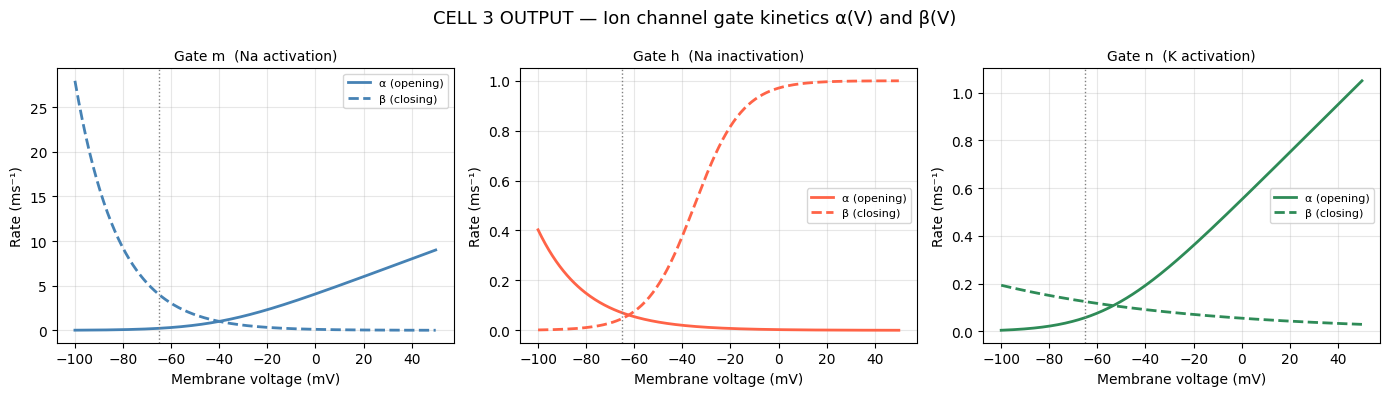

→ At rest (-65 mV) gates are nearly closed.
→ As V rises (depolarisation), α_m explodes: Na channels SNAP open.
→ Then β_h rises: h gate closes Na (inactivation — refractory period).


In [ ]:
# Gate Kinetics (α and β rate functions)
#
# Define how fast ion channel gates open/close.
#Each ion channel has "gates":
#         Na has m (activation) and h (inactivation)
#         K  has n (activation)
#       α(V) = rate of OPENING at voltage V
#       β(V) = rate of CLOSING  at voltage V
#
# These are empirical sigmoid functions fitted by HH to their
# voltage-clamp data. They are the heart of the model.
# ═══════════════════════════════════════════════════════════════

def alpha_m(V):
    """Na activation opening rate. Peaks near threshold."""
    return 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10) + 1e-9)

def beta_m(V):
    """Na activation closing rate."""
    return 4.0 * np.exp(-(V + 65) / 18)

def alpha_h(V):
    """Na inactivation opening rate (h gate closes Na at peak)."""
    return 0.07 * np.exp(-(V + 65) / 20)

def beta_h(V):
    """Na inactivation closing rate."""
    return 1.0 / (1 + np.exp(-(V + 35) / 10))

def alpha_n(V):
    """K activation opening rate."""
    return 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10) + 1e-9)

def beta_n(V):
    """K activation closing rate."""
    return 0.125 * np.exp(-(V + 65) / 80)

# --- Visualise the gate kinetics curves ---
V_range = np.linspace(-100, 50, 300)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("CELL 3 OUTPUT — Ion channel gate kinetics α(V) and β(V)", fontsize=13)

for ax, (a_func, b_func, label, color) in zip(axes, [
    (alpha_m, beta_m, "m  (Na activation)",   "steelblue"),
    (alpha_h, beta_h, "h  (Na inactivation)", "tomato"),
    (alpha_n, beta_n, "n  (K activation)",    "seagreen"),
]):
    ax.plot(V_range, [a_func(v) for v in V_range], label="α (opening)", color=color, lw=2)
    ax.plot(V_range, [b_func(v) for v in V_range], label="β (closing)", color=color, lw=2, ls='--')
    ax.set_title(f"Gate {label}", fontsize=10)
    ax.set_xlabel("Membrane voltage (mV)")
    ax.set_ylabel("Rate (ms⁻¹)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axvline(-65, color='gray', lw=1, ls=':', label='rest')

plt.tight_layout()
plt.show()



In [ ]:
# Steady-state gate variables at rest
V_rest = -65.0  # mV — resting membrane potential

m_inf = alpha_m(V_rest) / (alpha_m(V_rest) + beta_m(V_rest))
h_inf = alpha_h(V_rest) / (alpha_h(V_rest) + beta_h(V_rest))
n_inf = alpha_n(V_rest) / (alpha_n(V_rest) + beta_n(V_rest))

print("Steady-state gate values at V_rest =", V_rest, "mV")
print(f"  m∞ = {m_inf:.4f}  (Na activation — nearly 0 : channels mostly closed)")
print(f"  h∞ = {h_inf:.4f}  (Na inactivation — near 0.6 : partially available)")
print(f"  n∞ = {n_inf:.4f}  (K activation — small : K channels mostly closed)")
print()
print("Initial state vector y0 = [V, m, h, n]:")
y0 = [V_rest, m_inf, h_inf, n_inf]
print(f"  y0 = {[round(v, 4) for v in y0]}")

Steady-state gate values at V_rest = -65.0 mV
  m∞ = 0.0529  (Na activation — nearly 0 → channels mostly closed)
  h∞ = 0.5961  (Na inactivation — near 0.6 → partially available)
  n∞ = 0.3177  (K activation — small → K channels mostly closed)

Initial state vector y0 = [V, m, h, n]:
  y0 = [-65.0, np.float64(0.0529), np.float64(0.5961), np.float64(0.3177)]


In [ ]:
#The HH Differential Equations
#H-H model. Four equations, four unknowns:
#         dV/dt  — how voltage changes (driven by ion currents)
#         dm/dt  — how Na activation gate changes
#         dh/dt  — how Na inactivation gate changes
#         dn/dt  — how K activation gate changes
#
# The external current I_ext is what the ELECTRODE delivers.
# As the electrode degrades, I_ext shrinks


def hh_odes(t, y, I_ext):
    """
    The Hodgkin-Huxley ODEs.

    Parameters
    ----------
    t     : current time (ms)
    y     : [V, m, h, n]
    I_ext : external stimulus current (µA/cm²) — scalar, constant per call

    Returns
    -------
    [dV/dt, dm/dt, dh/dt, dn/dt]
    """
    V, m, h, n = y

    # --- Ionic currents ---
    I_Na  = g_Na * m**3 * h * (V - E_Na)   # Na inward (depolarising)
    I_K   = g_K  * n**4     * (V - E_K)    # K outward (repolarising)
    I_L   = g_L             * (V - E_L)    # Leak

    # --- Voltage equation (capacitor = sum of currents) ---
    dVdt = (I_ext - I_Na - I_K - I_L) / C_m

    # --- Gate equations ---
    dmdt = alpha_m(V) * (1 - m) - beta_m(V) * m
    dhdt = alpha_h(V) * (1 - h) - beta_h(V) * h
    dndt = alpha_n(V) * (1 - n) - beta_n(V) * n

    return [dVdt, dmdt, dhdt, dndt]

print("hh_odes() defined.")
print()
print("At rest (V=-65, I_ext=0), the net current should be ~0:")
dVdt_rest, *_ = hh_odes(0, y0, I_ext=0.0)
print(f"  dV/dt at rest = {dVdt_rest:.6f} mV/ms  (should be near 0)")


hh_odes() defined.

At rest (V=-65, I_ext=0), the net current should be ~0:
  dV/dt at rest = 0.000324 mV/ms  (should be near 0)


Simulation complete.
  Duration      : 300.0 ms
  Stimulus      : 10.0 µA/cm²  from t=50.0 to t=250.0 ms
  Action potentials fired: 14


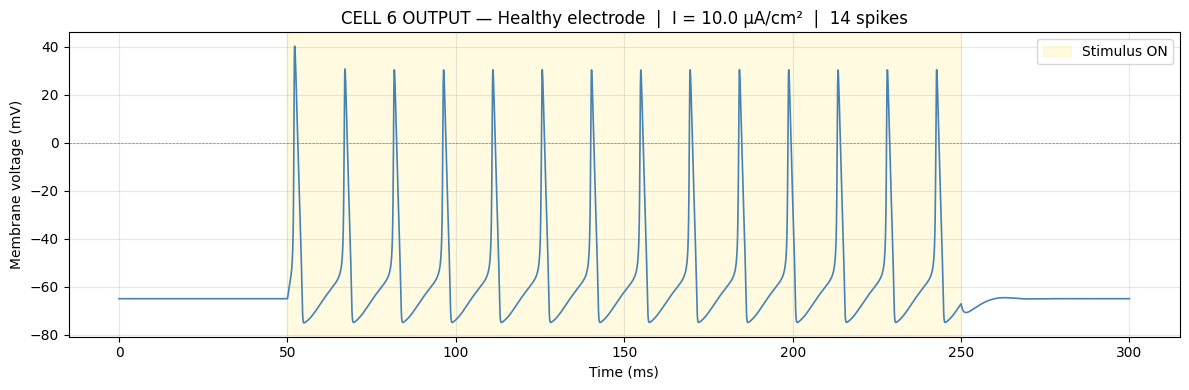

In [ ]:
#  Run one simulation: healthy electrode (I = 10 µA/cm²)
# Solving the ODEs for 300 ms with a 100 ms stimulus at 10 µA/cm².
# This is our "baseline" for healthy DBS pulse train.
#       We use a square pulse (constant I during stim window).

# ═══════════════════════════════════════════════════════════════

T_SIM       = 300.0   # ms — total simulation time
STIM_START  = 50.0    # ms — stimulus onset
STIM_END    = 250.0   # ms — stimulus offset
I_nominal   = 10.0    # µA/cm² (intended) current

def run_hh(I_amplitude, t_end=T_SIM):
    """
    Solve HH model for a constant square-pulse stimulus.
    Returns (t_array, V_array, n_spikes).
    """
    def rhs(t, y):

        I = I_amplitude if STIM_START <= t <= STIM_END else 0.0
        return hh_odes(t, y, I)

    sol = solve_ivp(
        rhs,
        t_span=(0, t_end),
        y0=y0,
        method='RK45',      # Runge-Kutta 4th/5th order adaptive step
        max_step=0.05,
        dense_output=False
    )

    V = sol.y[0]            # membrane voltage trace
    t = sol.t               # time points


    peaks, _ = find_peaks(V, height=0.0, distance=int(5 / 0.05))
    return t, V, len(peaks)

# Run baseline simulation
t, V, n_spikes = run_hh(I_nominal)

print(f"Simulation complete.")
print(f"  Duration      : {T_SIM} ms")
print(f"  Stimulus      : {I_nominal} µA/cm²  from t={STIM_START} to t={STIM_END} ms")
print(f"  Action potentials fired: {n_spikes}")

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, V, color='steelblue', lw=1.2)
ax.axvspan(STIM_START, STIM_END, alpha=0.12, color='gold', label='Stimulus ON')
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Membrane voltage (mV)")
ax.set_title(f"CELL 6 OUTPUT — Healthy electrode  |  I = {I_nominal} µA/cm²  |  {n_spikes} spikes")
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

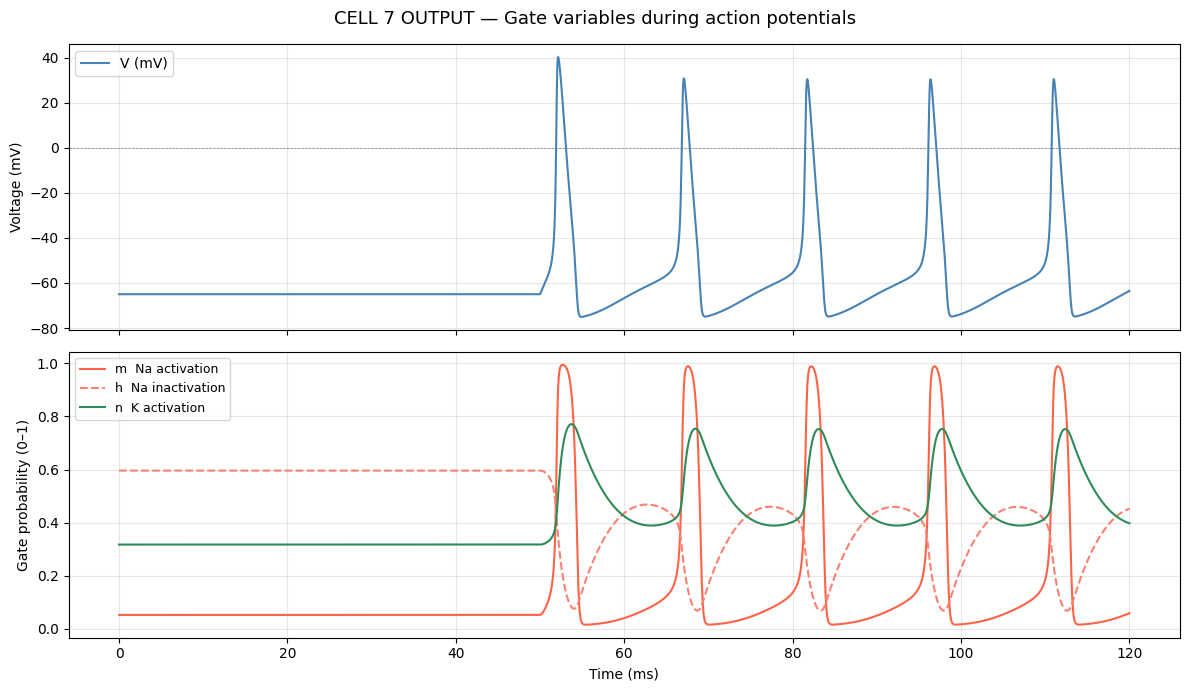

Read the plot like a story:
  1. Stimulus arrives → m shoots up → Na channels open → V spikes upward
  2. h falls → Na channels inactivate → spike peaks
  3. n rises → K channels open → V repolarises quickly
  4. h recovers, m resets → neuron ready to fire again


In [ ]:
#  Inspect the gating variables during spiking
#
#Plot V, m, h, n together to see what each gate does during a spike.
#       WHY reducing current stops firing (m never reaches threshold).


def run_hh_full(I_amplitude, t_end=T_SIM):

    def rhs(t, y):
        I = I_amplitude if STIM_START <= t <= STIM_END else 0.0
        return hh_odes(t, y, I)

    sol = solve_ivp(rhs, (0, t_end), y0, method='RK45', max_step=0.05)
    return sol.t, sol.y[0], sol.y[1], sol.y[2], sol.y[3]

t, V, m, h, n = run_hh_full(I_nominal)

# Zoom into first 2 spikes
mask = t < 120

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("CELL 7 OUTPUT — Gate variables during action potentials", fontsize=13)

axes[0].plot(t[mask], V[mask], color='steelblue', lw=1.5, label='V (mV)')
axes[0].set_ylabel("Voltage (mV)")
axes[0].axhline(0, color='gray', lw=0.5, ls='--')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t[mask], m[mask], color='tomato',   lw=1.5, label='m  Na activation')
axes[1].plot(t[mask], h[mask], color='salmon',   lw=1.5, ls='--', label='h  Na inactivation')
axes[1].plot(t[mask], n[mask], color='seagreen', lw=1.5, label='n  K activation')
axes[1].set_ylabel("Gate probability (0–1)")
axes[1].set_xlabel("Time (ms)")
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("  1. Stimulus arrives → m shoots up → Na channels open → V spikes upward")
print("  2. h falls → Na channels inactivate → spike peaks")
print("  3. n rises → K channels open → V repolarises quickly")
print("  4. h recovers, m resets → neuron ready to fire again")


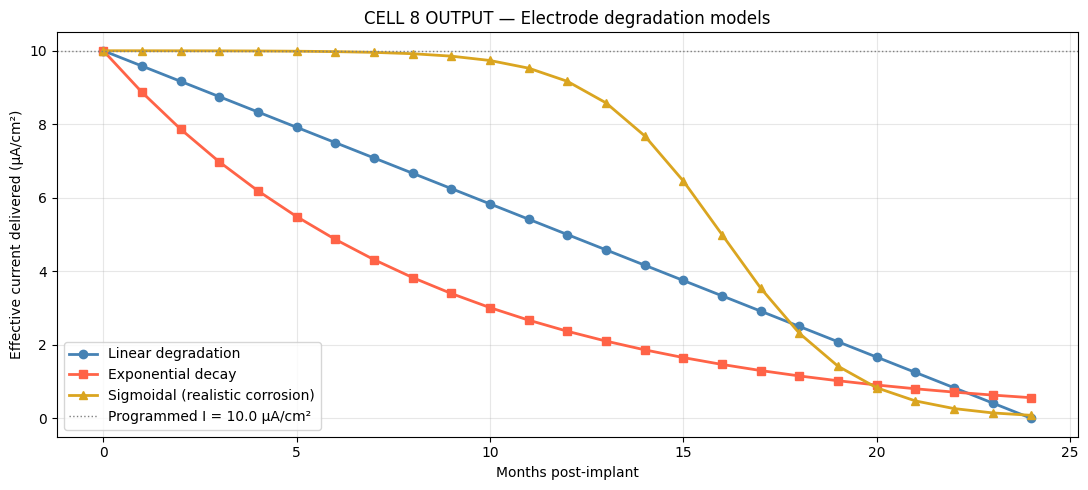

Table of effective current by month:
 Month    Linear   Exponential   Sigmoid
     0     10.00         10.00     10.00
     4      8.33          6.19      9.99
     8      6.67          3.83      9.92
    12      5.00          2.37      9.17
    16      3.33          1.47      5.00
    18      2.50          1.15      2.31
    20      1.67          0.91      0.83
    24      0.00          0.56      0.08


In [ ]:
# The Electrode Degradation Models
#
# how effective current I_eff(month) decays over time.
#       voltage pulse delivers less actual charge to the neuron.
#       Three physics-motivated models:
#         Linear    : uniform wear (optimistic)
#         Exponential: fast early decay, slow later (chemical corrosion)
#         Sigmoidal  : stable for a long time, then sudden collapse
#                      ← this is what leads to "silent failure"
# ═══════════════════════════════════════════════════════════════

months = np.arange(0, 25)   # month 0 to 24

def linear_degradation(t, T_life=24):
    return np.clip(1 - t / T_life, 0, 1)

def exponential_degradation(t, lam=0.12):
    return np.exp(-lam * t)

def sigmoid_degradation(t, k=0.6, t_mid=16):
    """
    Sigmoidal decay: stays near 1.0 for a long time,
    then collapses rapidly around t_mid.
    k controls steepness of the drop.
    """
    return 1.0 / (1 + np.exp(k * (t - t_mid)))

# Compute effective current for each model
I_linear = I_nominal * linear_degradation(months)
I_exp    = I_nominal * exponential_degradation(months)
I_sig    = I_nominal * sigmoid_degradation(months)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(months, I_linear, 'o-', color='steelblue',  lw=2, label='Linear degradation')
ax.plot(months, I_exp,    's-', color='tomato',     lw=2, label='Exponential decay')
ax.plot(months, I_sig,    '^-', color='goldenrod',  lw=2, label='Sigmoidal (realistic corrosion)')
ax.axhline(I_nominal, color='gray', lw=1, ls=':', label=f'Programmed I = {I_nominal} µA/cm²')
ax.set_xlabel("Months post-implant")
ax.set_ylabel("Effective current delivered (µA/cm²)")
ax.set_title("CELL 8 OUTPUT — Electrode degradation models")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Table of effective current by month:")
print(f"{'Month':>6}  {'Linear':>8}  {'Exponential':>12}  {'Sigmoid':>8}")
for m_val in [0, 4, 8, 12, 16, 18, 20, 24]:
    il = I_nominal * linear_degradation(m_val)
    ie = I_nominal * exponential_degradation(m_val)
    isg = I_nominal * sigmoid_degradation(m_val)
    print(f"{m_val:>6}  {il:>8.2f}  {ie:>12.2f}  {isg:>8.2f}")


Sweeping current values — this takes ~1 minute...
  I =  0.00 µA/cm²  →   0 spikes
  I =  0.34 µA/cm²  →   0 spikes
  I =  0.68 µA/cm²  →   0 spikes
  I =  1.02 µA/cm²  →   0 spikes
  I =  1.36 µA/cm²  →   0 spikes
  I =  1.69 µA/cm²  →   0 spikes
  I =  2.03 µA/cm²  →   0 spikes
  I =  2.37 µA/cm²  →   1 spikes
  I =  2.71 µA/cm²  →   1 spikes
  I =  3.05 µA/cm²  →   1 spikes
  I =  3.39 µA/cm²  →   1 spikes
  I =  3.73 µA/cm²  →   1 spikes
  I =  4.07 µA/cm²  →   1 spikes
  I =  4.41 µA/cm²  →   1 spikes
  I =  4.75 µA/cm²  →   1 spikes
  I =  5.08 µA/cm²  →   1 spikes
  I =  5.42 µA/cm²  →   1 spikes
  I =  5.76 µA/cm²  →   1 spikes
  I =  6.10 µA/cm²  →   2 spikes
  I =  6.44 µA/cm²  →  11 spikes
  I =  6.78 µA/cm²  →  12 spikes
  I =  7.12 µA/cm²  →  12 spikes
  I =  7.46 µA/cm²  →  13 spikes
  I =  7.80 µA/cm²  →  13 spikes
  I =  8.14 µA/cm²  →  13 spikes
  I =  8.47 µA/cm²  →  13 spikes
  I =  8.81 µA/cm²  →  13 spikes
  I =  9.15 µA/cm²  →  14 spikes
  I =  9.49 µA/cm²  →  14 

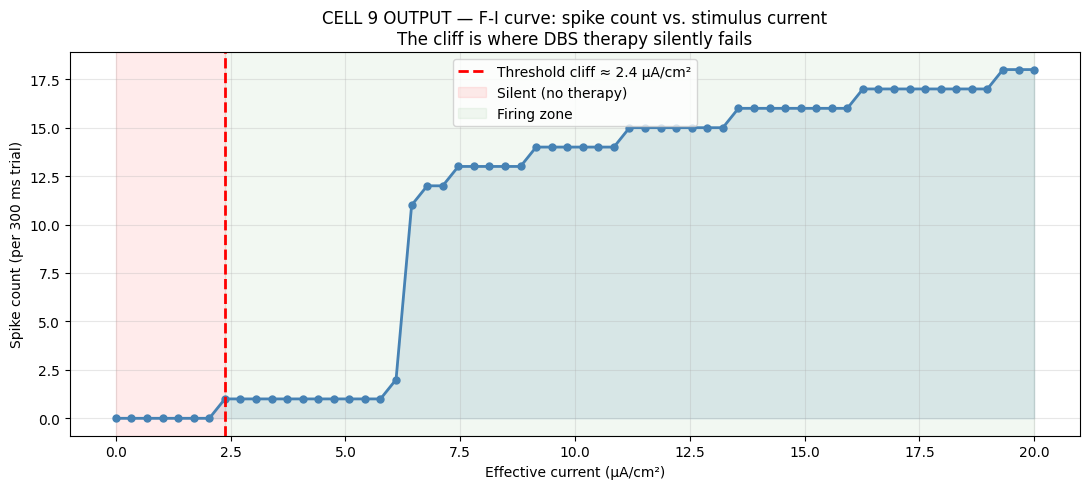

In [ ]:
# The F-I Curve: Finding the Firing Threshold "Cliff"
#
# Sweep current from 0 to 20 µA/cm², count spikes at each value.


print("Sweeping current values")
I_sweep = np.linspace(0, 20, 60)   # 60 values from 0 to 20 µA/cm²
spike_counts = []

for I_val in I_sweep:
    _, _, n = run_hh(I_val)
    spike_counts.append(n)
    print(f"  I = {I_val:5.2f} µA/cm²  →  {n:2d} spikes", flush=True)

spike_counts = np.array(spike_counts)

# Find threshold: lowest current that still produces ≥ 1 spike
firing = spike_counts > 0
I_threshold = I_sweep[firing][0] if firing.any() else None

print(f"\n→ Firing threshold cliff at I ≈ {I_threshold:.2f} µA/cm²")
print(f"  Below this: 0 spikes.  Above this: spikes return immediately.")
print(f"  The transition is SUDDEN, not gradual — this is the cliff.")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(I_sweep, spike_counts, 'o-', color='steelblue', lw=2, ms=5)
ax.fill_between(I_sweep, spike_counts, alpha=0.15, color='steelblue')
if I_threshold:
    ax.axvline(I_threshold, color='red', lw=2, ls='--',
               label=f'Threshold cliff ≈ {I_threshold:.1f} µA/cm²')
    ax.axvspan(0, I_threshold, alpha=0.08, color='red', label='Silent (no therapy)')
    ax.axvspan(I_threshold, 20, alpha=0.05, color='green', label='Firing zone')
ax.set_xlabel("Effective current (µA/cm²)")
ax.set_ylabel("Spike count (per 300 ms trial)")
ax.set_title("CELL 9 OUTPUT — F-I curve: spike count vs. stimulus current\n"
             "The cliff is where DBS therapy silently fails")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Running 24-month aging simulation for 3 models...
  Linear        month  0  I_eff=10.00  spikes=14
  Linear        month  1  I_eff=9.58  spikes=14
  Linear        month  2  I_eff=9.17  spikes=14
  Linear        month  3  I_eff=8.75  spikes=13
  Linear        month  4  I_eff=8.33  spikes=13
  Linear        month  5  I_eff=7.92  spikes=13
  Linear        month  6  I_eff=7.50  spikes=13
  Linear        month  7  I_eff=7.08  spikes=12
  Linear        month  8  I_eff=6.67  spikes=12
  Linear        month  9  I_eff=6.25  spikes=6
  Linear        month 10  I_eff=5.83  spikes=1
  Linear        month 11  I_eff=5.42  spikes=1
  Linear        month 12  I_eff=5.00  spikes=1
  Linear        month 13  I_eff=4.58  spikes=1
  Linear        month 14  I_eff=4.17  spikes=1
  Linear        month 15  I_eff=3.75  spikes=1
  Linear        month 16  I_eff=3.33  spikes=1
  Linear        month 17  I_eff=2.92  spikes=1
  Linear        month 18  I_eff=2.50  spikes=1
  Linear        month 19  I_eff=2.08  spikes=0


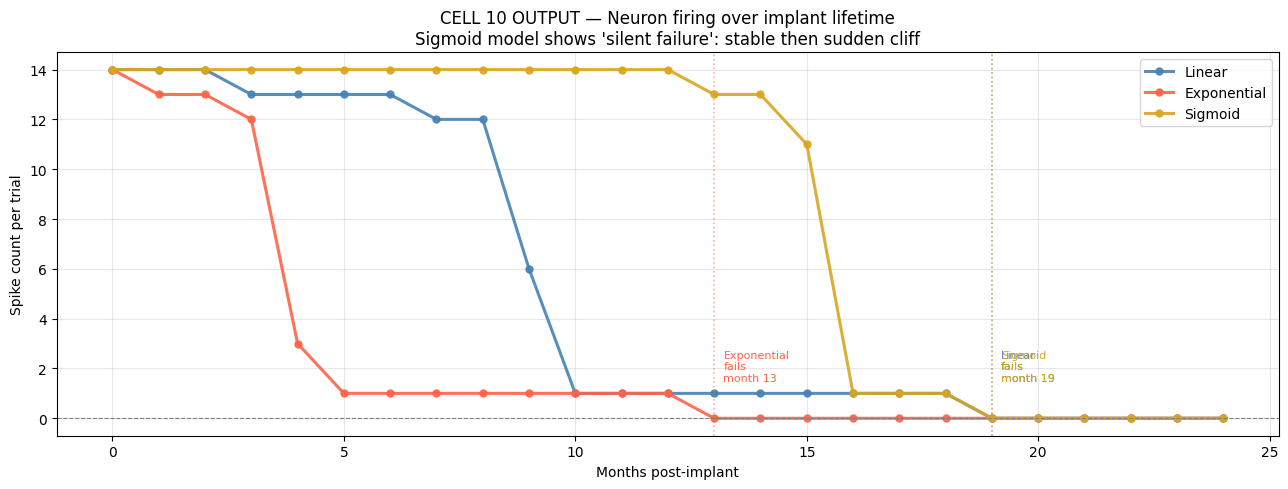


Summary table — first month of complete failure:
  Linear      : month 19
  Exponential : month 13
  Sigmoid     : month 19


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  Simulate Aging: Spikes Over 24 Months
#
# What: For each month, compute I_eff, run HH, record spike count.
# Why:  This is the main clinical story.

print("Running 24-month aging simulation for 3 models...")
results = {}

for model_name, I_series in [
    ('Linear',      I_linear),
    ('Exponential', I_exp),
    ('Sigmoid',     I_sig),
]:
    spikes = []
    for month_idx, I_eff in enumerate(I_series):
        _, _, n = run_hh(I_eff)
        spikes.append(n)
        print(f"  {model_name:12s}  month {month_idx:2d}  I_eff={I_eff:.2f}  spikes={n}")
    results[model_name] = np.array(spikes)

print("\nDone!")

fig, ax = plt.subplots(figsize=(13, 5))
colors = {'Linear': 'steelblue', 'Exponential': 'tomato', 'Sigmoid': 'goldenrod'}

for name, spikes in results.items():
    ax.plot(months, spikes, 'o-', color=colors[name], lw=2.2,
            ms=5, label=name, alpha=0.9)

    # Mark first month of failure
    fail = months[spikes == 0]
    if len(fail):
        ax.axvline(fail[0], color=colors[name], lw=1.2, ls=':', alpha=0.5)
        ax.text(fail[0] + 0.2, 1.5, f'{name}\nfails\nmonth {fail[0]}',
                color=colors[name], fontsize=8)

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel("Months post-implant")
ax.set_ylabel("Spike count per trial")
ax.set_title("CELL 10 OUTPUT — Neuron firing over implant lifetime\n"
             "Sigmoid model shows 'silent failure': stable then sudden cliff")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary table — first month of complete failure:")
for name, spikes in results.items():
    fail = months[spikes == 0]
    print(f"  {name:12s}: {'month ' + str(fail[0]) if len(fail) else 'never fails in 24 months'}")

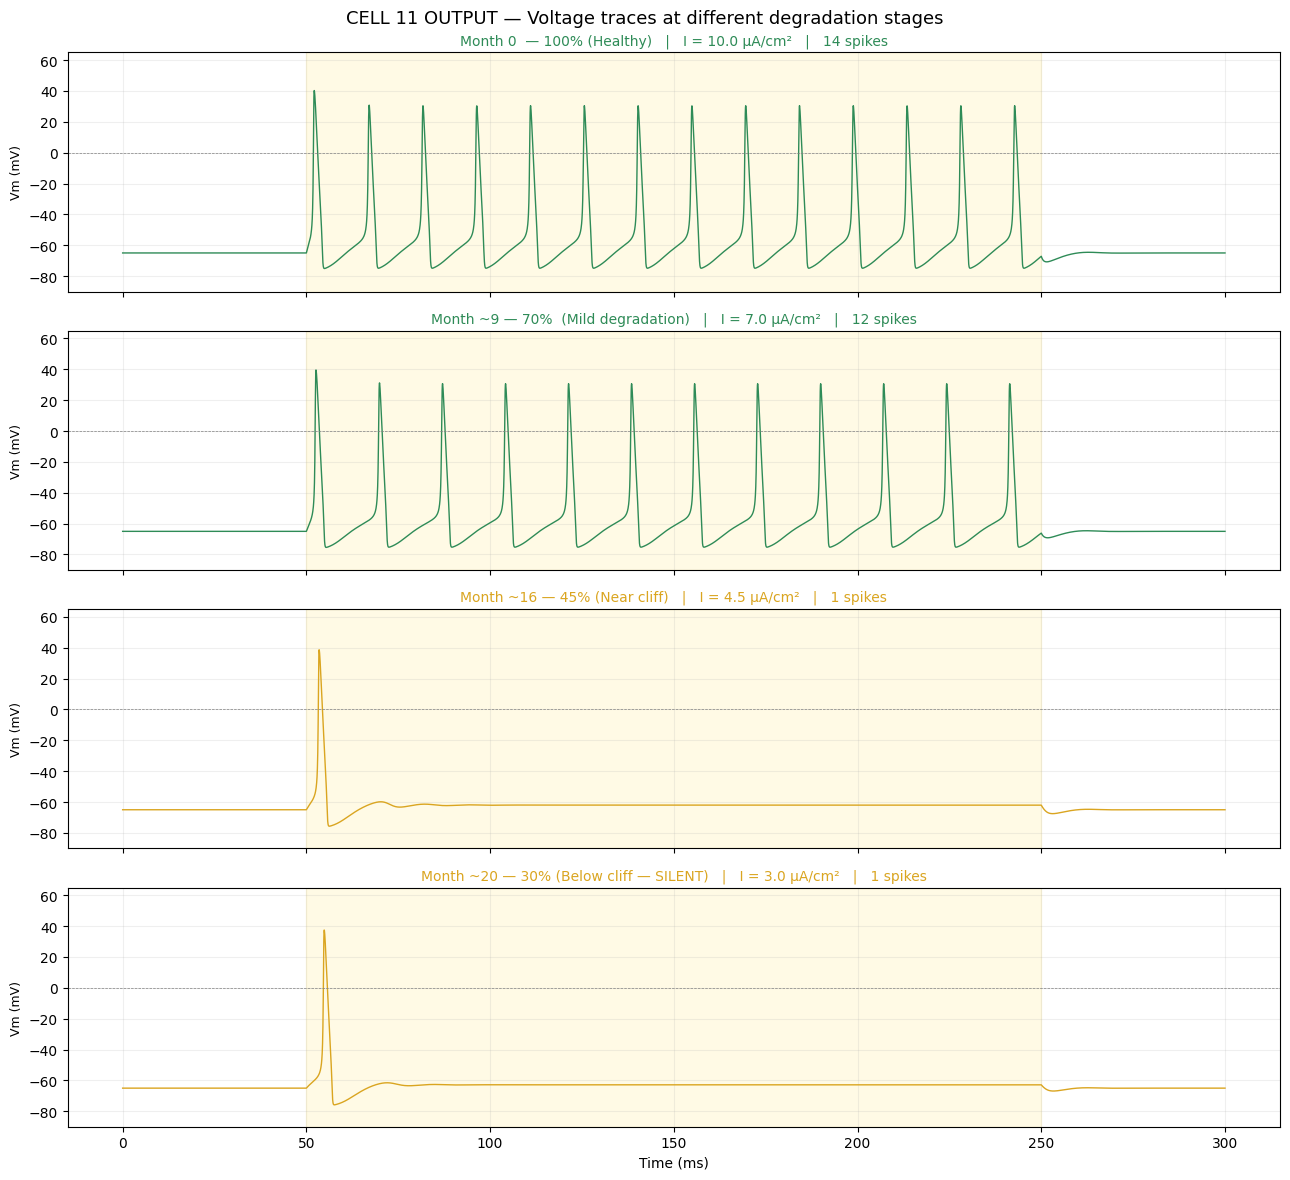

Key observation:
  70% current → still fires well (mild signal loss, no symptoms)
  45% current → fires weakly near threshold
  30% current → complete silence, same as no implant
  Patient at 45→30% crosses the cliff with NO gradual warning.


In [ ]:
# Compare Voltage Traces at Different Degradation Stages

stages = [
    (I_nominal * 1.0,  "Month 0  — 100% (Healthy)"),
    (I_nominal * 0.7,  "Month ~9 — 70%  (Mild degradation)"),
    (I_nominal * 0.45, "Month ~16 — 45% (Near cliff)"),
    (I_nominal * 0.3,  "Month ~20 — 30% (Below cliff — SILENT)"),
]

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
fig.suptitle("CELL 11 OUTPUT — Voltage traces at different degradation stages", fontsize=13)

for ax, (I_val, label) in zip(axes, stages):
    t, V, n = run_hh(I_val)
    color = 'seagreen' if n > 3 else ('goldenrod' if n > 0 else 'red')
    ax.plot(t, V, color=color, lw=1.0)
    ax.axvspan(STIM_START, STIM_END, alpha=0.1, color='gold')
    ax.set_ylabel("Vm (mV)", fontsize=9)
    ax.set_title(f"{label}   |   I = {I_val:.1f} µA/cm²   |   {n} spikes",
                 fontsize=10, color=color)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_ylim(-90, 65)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

print("Key observation:")
print("  70% current → still fires well (mild signal loss, no symptoms)")
print("  45% current → fires weakly near threshold")
print("  30% current → complete silence, same as no implant")
print("  Patient at 45→30% crosses the cliff with NO gradual warning.")



Computing spike reliability near threshold (takes ~2 min)...
  I = 1.19 µA/cm²  →  dropout rate = 1.00
  I = 1.40 µA/cm²  →  dropout rate = 1.00
  I = 1.61 µA/cm²  →  dropout rate = 1.00
  I = 1.81 µA/cm²  →  dropout rate = 1.00
  I = 2.02 µA/cm²  →  dropout rate = 1.00
  I = 2.23 µA/cm²  →  dropout rate = 0.47
  I = 2.44 µA/cm²  →  dropout rate = 0.13
  I = 2.65 µA/cm²  →  dropout rate = 0.00
  I = 2.86 µA/cm²  →  dropout rate = 0.00
  I = 3.07 µA/cm²  →  dropout rate = 0.00
  I = 3.28 µA/cm²  →  dropout rate = 0.00
  I = 3.49 µA/cm²  →  dropout rate = 0.00
  I = 3.70 µA/cm²  →  dropout rate = 0.00
  I = 3.91 µA/cm²  →  dropout rate = 0.00
  I = 4.12 µA/cm²  →  dropout rate = 0.00
  I = 4.33 µA/cm²  →  dropout rate = 0.00
  I = 4.54 µA/cm²  →  dropout rate = 0.00
  I = 4.75 µA/cm²  →  dropout rate = 0.00


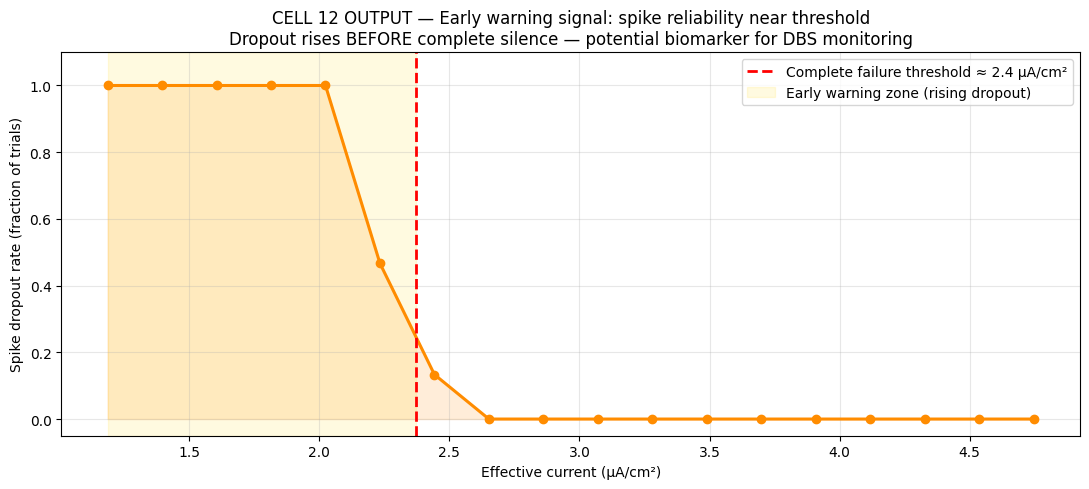


Conclusion:
  Dropout rate starts rising ABOVE threshold current.
  → This gives a detectable warning window before therapy fails.
  → In a real DBS system, an embedded sensor could track this
    and alert clinician to replace/reprogram before patient notices.


In [ ]:
# Early Warning Signal: Spike Reliability Near Threshold
#
# small noise to current, measure how often spikes DROP OUT.
# Method: For each probe current, run 15 trials with ±5% noise.
#         Dropout = fraction of trials with fewer spikes than expected.
# ═══════════════════════════════════════════════════════════════

print("Computing spike reliability near threshold (takes ~2 min)...")

if I_threshold:
    probe_currents = np.linspace(I_threshold * 0.5, I_threshold * 2.0, 18)
else:
    probe_currents = np.linspace(2, 14, 18)

N_TRIALS    = 15    # trials per current level
NOISE_LEVEL = 0.05  # 5% Gaussian noise on current

# Reference spike count at 1.5× threshold (clean signal)
_, _, n_ref = run_hh(probe_currents[-1])
n_ref = max(n_ref, 1)

dropout_rates = []
for I_probe in probe_currents:
    dropouts = 0
    for _ in range(N_TRIALS):
        I_noisy = I_probe * (1 + np.random.normal(0, NOISE_LEVEL))
        I_noisy = max(I_noisy, 0.0)
        _, _, n = run_hh(I_noisy)
        if n < 0.5 * n_ref:    # dropped out if less than half expected
            dropouts += 1
    rate = dropouts / N_TRIALS
    dropout_rates.append(rate)
    print(f"  I = {I_probe:.2f} µA/cm²  →  dropout rate = {rate:.2f}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(probe_currents, dropout_rates, 'o-', color='darkorange', lw=2.2, ms=6)
ax.fill_between(probe_currents, dropout_rates, alpha=0.15, color='darkorange')
if I_threshold:
    ax.axvline(I_threshold, color='red', lw=2, ls='--',
               label=f'Complete failure threshold ≈ {I_threshold:.1f} µA/cm²')
    # Highlight the warning window (above threshold where dropout starts rising)
    warn_zone = probe_currents[np.array(dropout_rates) > 0.1]
    if len(warn_zone):
        ax.axvspan(warn_zone[0], I_threshold, alpha=0.12, color='gold',
                   label='Early warning zone (rising dropout)')

ax.set_xlabel("Effective current (µA/cm²)")
ax.set_ylabel("Spike dropout rate (fraction of trials)")
ax.set_title("CELL 12 OUTPUT — Early warning signal: spike reliability near threshold\n"
             "Dropout rises BEFORE complete silence — potential biomarker for DBS monitoring")
ax.set_ylim(-0.05, 1.1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nConclusion:")
print("  Dropout rate starts rising ABOVE threshold current.")
print("  → This gives a detectable warning window before therapy fails.")
print("  → In a real DBS system, an embedded sensor could track this")
print("    and alert clinician to replace/reprogram before patient notices.")


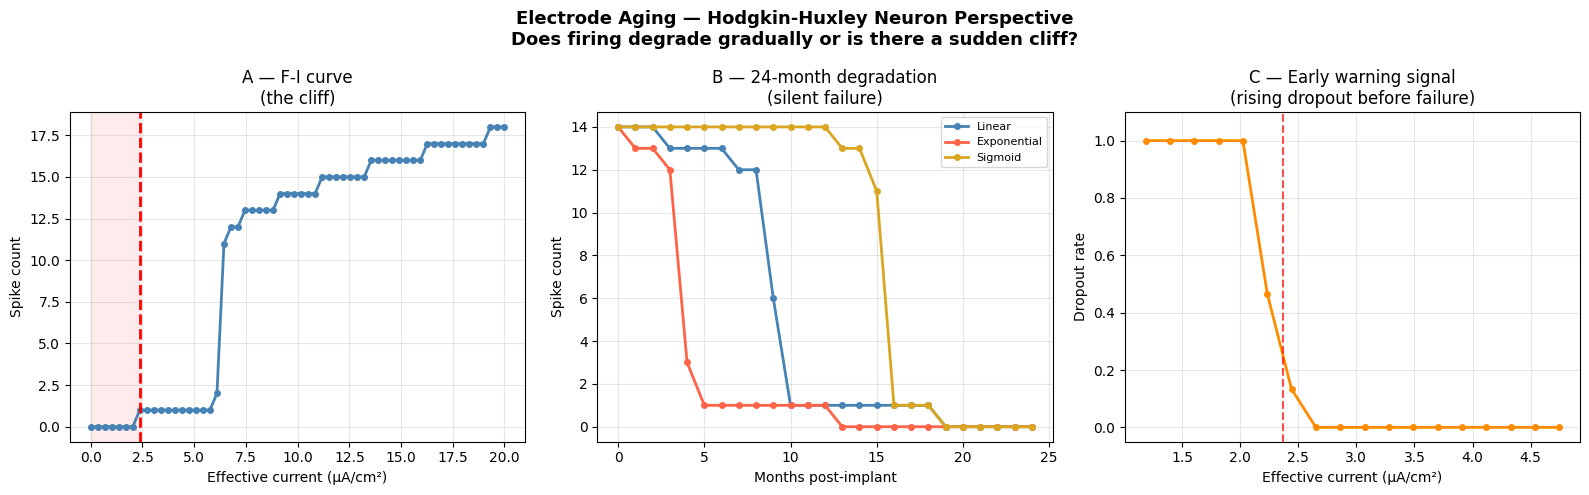

Figure saved as summary_figure.png


In [ ]:


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Electrode Aging — Hodgkin-Huxley Neuron Perspective\n"
             "Does firing degrade gradually or is there a sudden cliff?",
             fontsize=13, fontweight='bold')

# Panel A: F-I curve
ax = axes[0]
ax.plot(I_sweep, spike_counts, 'o-', color='steelblue', lw=2, ms=4)
if I_threshold:
    ax.axvline(I_threshold, color='red', lw=2, ls='--')
    ax.axvspan(0, I_threshold, alpha=0.08, color='red')
ax.set_xlabel("Effective current (µA/cm²)")
ax.set_ylabel("Spike count")
ax.set_title("A — F-I curve\n(the cliff)")
ax.grid(True, alpha=0.3)

# Panel B: Aging curves
ax = axes[1]
for name, spikes in results.items():
    ax.plot(months, spikes, 'o-', color=colors[name], lw=2, ms=4, label=name)
ax.set_xlabel("Months post-implant")
ax.set_ylabel("Spike count")
ax.set_title("B — 24-month degradation\n(silent failure)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel C: Dropout
ax = axes[2]
ax.plot(probe_currents, dropout_rates, 'o-', color='darkorange', lw=2, ms=4)
if I_threshold:
    ax.axvline(I_threshold, color='red', lw=1.5, ls='--', alpha=0.7)
ax.set_xlabel("Effective current (µA/cm²)")
ax.set_ylabel("Dropout rate")
ax.set_title("C — Early warning signal\n(rising dropout before failure)")
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('summary_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as summary_figure.png")